# Thematic and Sentiment Analysis of LLM-Generated Dialogue

## Objective
To quantify the thematic flow and emotional trajectory of an AI-generated conversation to determine if the underlying Large Language Model (LLM) successfully adheredred prompt constraints. 

## Executive Overview
This analysis evaluates a synthetically generated dinner party conversation featuring a curated list of historical and contemporary figures. The initial prompt requested a specific balance of "intelligent but approachable" dialogue, professional diversity, and a humorous tone. 

To systematically evaluate the LLM's output against these constraints, this project employs a natural language processing (NLP) pipeline to deconstruct the unstructured text across three core dimensions:

* **The "Who" (Entity Resolution):** Utilizing rule-based Named Entity Recognition (NER) to verify the presence and distribution of the requested social anchors, overcoming the limitations of standard statistical models on formatted text.
* **The "When" (Sentiment Trajectory):** Applying lexicon-based sentiment analysis with rolling averages to map the emotional flow and identify structural shifts in the conversation's tone.
* **The "What" (Topic Modeling & Frequency):** Leveraging N-gram tokenization and Latent Dirichlet Allocation (LDA) to extract latent semantic themes (the "Topic Zeitgeist") and isolate the defining attributes of the text.

## Assumptions, Limitations, and Methodological Trade-offs

A critical component of this analysis involves understanding the boundaries of the applied Natural Language Processing (NLP) models. Placing these limitations upfront provides crucial context for interpreting the visualizations that follow. The unstructured, highly contextual, and formatted nature of LLM-generated dialogue introduces specific challenges:

### 1. Lexicon-Based Sentiment Blindspots (The Context Gap)
The sentiment timeline utilizes `TextBlob`, a lexicon-based model that calculates polarity by looking up individual words in a predefined dictionary. 
* **The Limitation:** This approach lacks a contextual understanding of sarcasm, self-deprecation, and complex humor. 
* **Example in Data:** During the "Accidental Genius" icebreaker, a guest proudly recounted a successful business origin story involving "ruined tights" and a "lack of planning." Because of these negatively weighted words, the model erroneously scored this triumphant, humorous moment as the most severe negative dip in the conversation (Polarity: -0.94).

### 2. Statistical NER vs. LLM Formatting Noise
Initial entity extraction was attempted using spaCy's standard statistical model (`en_core_web_sm`). 
* **The Limitation:** The model struggled to parse the LLM's specific typography, including Markdown bolding (`**`) and citation brackets (``), resulting in entity fragmentation (treating "Ben" and "Benjamin Franklin" as separate people) and false positives (identifying "Spanx" as a person).
* **The Solution:** To guarantee accuracy, the pipeline was pivoted to a rule-based `PhraseMatcher` coupled with an Entity Resolution dictionary. This methodological shift prioritized 100% accuracy on a known entity list over the exploratory guesses of a statistical model.

### 3. Topic Modeling on Micro-Corpora
Latent Dirichlet Allocation (LDA) is fundamentally designed for massive datasets containing thousands of distinct documents. 
* **The Limitation:** Applying LDA to a single, 1,500-word conversation requires aggressive data manipulation. 
* **The Solution:** The text was programmatically sliced into three temporal chunks (Setup, Icebreakers, Conversation) to force document variance. While the use of Bigrams (`Phraser`) successfully preserved semantic phrasing like `hot_potato`, the resulting "Topic Zeitgeist" still produced a mathematically weak "background noise" topic, which is a standard mathematical artifact when forcing a multi-topic distribution on a micro-corpus.n a micro-corpus.

In [14]:
%%capture

# Install dependencies from the requirements file (for users not running Docker)
%pip install -r requirements.txt

# Download the required spaCy English language model
!python -m spacy download en_core_web_sm

In [2]:
# NLP & Text Processing
import spacy
from textblob import TextBlob
import gensim
from gensim.models.phrases import Phrases, Phraser
from gensim import corpora
import textwrap

# Data Manipulation
import pandas as pd
from collections import Counter
import numpy as np
from sklearn.decomposition import PCA

# Static Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Visualization
import plotly.graph_objects as go
import plotly.express as px
import networkx as nx
import itertools

In [3]:
nlp = spacy.load("en_core_web_sm")

# Read the unstructured conversation file
file_path = 'data/raw_data_llm_conversation.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Process the text through the spaCy pipeline 
doc = nlp(raw_text)

## Phase 1: Data Preprocessing & Named Entity Recognition (The "Who")

### Rationale & Methodology
Unstructured text generated by Large Language Models often contains formatting artifacts (e.g., Markdown bolding, citation tags) that degrade the performance of standard NLP pipelines. To accurately extract the "Who" of this conversation, a rigorous, multi-step entity resolution process was implemented:

* **Rule-Based Entity Matching:** Standard statistical Named Entity Recognition (NER) models (such as spaCy's `en_core_web_sm`) are prone to false positives (e.g., classifying "Spanx" as a PERSON) and entity fragmentation when applied to idiosyncratic conversational text. To enforce strict accuracy, the pipeline utilizes a `PhraseMatcher` built against a predefined gazetteer of the requested guest list.

* **Entity Normalization:** To ensure accurate frequency distributions for downstream visualization, an alias mapping dictionary was implemented. This resolves fragmented mentions (e.g., "Ben," "Ben Franklin," "Richard") back to their canonical entity identities ("Benjamin Franklin," "Richard Feynman").nman").

In [4]:
# Named Entity Recognition (NER) analysis
# Extract people (PERSON)
raw_entities = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]

# Entity Resolution Map to map variations to guest name
alias_map = {
    "Benjamin Franklin": "Benjamin Franklin",
    "Ben Franklin": "Benjamin Franklin",
    "Ben": "Benjamin Franklin",
    "Ann Richards": "Ann Richards",
    "Dolly Parton": "Dolly Parton",
    "Dolly": "Dolly Parton",
    "Trevor Noah": "Trevor Noah",
    "Richard Feynman": "Richard Feynman",
    "Richard": "Richard Feynman",
    "Jane Goodall": "Jane Goodall",
    "Jane": "Jane Goodall",
    "Steve Wozniak": "Steve Wozniak",
    "The Woz": "Steve Wozniak",
    "Sara Blakely": "Sara Blakely",
    "Maya Angelou": "Maya Angelou",
    "Julia Child": "Julia Child",
    "Julia": "Julia Child"
}

# Clean and filter entities
resolved_entities = []
for name in raw_entities:
    # Strip whitespace to prevent matching errors
    clean_name = name.strip()
    
    # If the name or a variation is in the map, add the official name to the new list
    if clean_name in alias_map:
        resolved_entities.append(alias_map[clean_name])

# Count and structure
guest_counts = Counter(resolved_entities).most_common(10)
df_guests = pd.DataFrame(guest_counts, columns=['Guest', 'Mentions'])

# Print Statements
print("-" * 30)
print("WHO: GUEST LIST VERIFICATION (RESOLVED)")
unique_guests = df_guests['Guest'].unique()
print(f"Total Unique Entities Found: {len(unique_guests)}")
print(f"Top Identified Guests: {', '.join(df_guests['Guest'].tolist())}")

------------------------------
WHO: GUEST LIST VERIFICATION (RESOLVED)
Total Unique Entities Found: 10
Top Identified Guests: Julia Child, Benjamin Franklin, Ann Richards, Richard Feynman, Jane Goodall, Dolly Parton, Steve Wozniak, Sara Blakely, Maya Angelou, Trevor Noah


## Phase 2: Sentiment Trajectory & Tone Analysis (The "When")

### Rationale & Methodology
To understand the dynamic flow of the dinner party, sentiment analysis was applied to map the emotional peaks and valleys of the dialogue over time. Rather than looking at the conversation as a static block of text, this phase treats the dialogue as time-series data to evaluate if the LLM maintained the requested "light and humorous" tone throughout the evening.

* **Lexicon-Based Scoring:** The cleaned corpus was tokenized into individual sentences, and each sentence was processed using `TextBlob` to calculate a polarity score ranging from -1.0 (highly negative) to 1.0 (highly positive). 
* **Temporal Smoothing (Rolling Averages):** Raw sentence-by-sentence sentiment is highly volatile, often resembling a chaotic heartbeat monitor due to micro-shifts in vocabulary. To extract the actual narrative arc and reveal macro-trends in the conversation's mood, a 5-sentence rolling average was engineered. 
* **Identifying Contextual Blindspots:** A critical finding of this analysis is the limitation of lexicon-based sentiment models when evaluating humanized, self-deprecating humor. For example, a triumphant and funny anecdote featuring the words "ruined," "disaster," and "embarrassing" was mathematically scored as the most severe negative moment in the conversation (Polarity: -0.94). Documenting this false negative highlights the inherent gap between statistical word-counting and genuine semantic understanding.

In [5]:
# Sentiment Analysis
sentiment_data = []

# Iterate through the sentences
for i, sent in enumerate(doc.sents):
    blob = TextBlob(sent.text)
    sentiment_data.append({
        'Sentence_Index': i,
        'Polarity': blob.sentiment.polarity,
        'Subjectivity': blob.sentiment.subjectivity,
        'Text': sent.text.strip()
    })

# Create the DataFrame
df_sentiment = pd.DataFrame(sentiment_data)

# Calculate the Rolling Average
df_sentiment['Rolling_Polarity'] = df_sentiment['Polarity'].rolling(window=5, min_periods=1).mean()

# Print Statements
print("\n" + "-" * 30)
print("WHEN: SENTIMENT & TONE SUMMARY")
avg_polarity = df_sentiment['Polarity'].mean()
avg_subjectivity = df_sentiment['Subjectivity'].mean()

most_pos_idx = df_sentiment['Polarity'].idxmax()
most_neg_idx = df_sentiment['Polarity'].idxmin()

print(f"Average Polarity (Mood): {avg_polarity:.2f} (Scale: -1 to 1)")
print(f"Average Subjectivity: {avg_subjectivity:.2f} (Scale: 0 to 1)")

print(f"\nMost Positive Moment (Score: {df_sentiment['Polarity'].iloc[most_pos_idx]:.2f}):")
print(f"'{df_sentiment['Text'].iloc[most_pos_idx]}'")

print(f"\nMost Negative Moment (Score: {df_sentiment['Polarity'].iloc[most_neg_idx]:.2f}):")
print(f"'{df_sentiment['Text'].iloc[most_neg_idx]}'")


------------------------------
WHEN: SENTIMENT & TONE SUMMARY
Average Polarity (Mood): 0.15 (Scale: -1 to 1)
Average Subjectivity: 0.48 (Scale: 0 to 1)

Most Positive Moment (Score: 1.00):
'"
Why it works: This perfectly bridges the gap between your guests.'

Most Negative Moment (Score: -0.94):
'Thus, Spanx was born from a pair of ruined tights and a lack of planning!"
Richard Feynman: (Leaning forward, eyes twinkling) "That’s high-level engineering, Sara!'


## Phase 3: Lexical Frequency & Attribute Extraction (The "What" and the "Tone")

### Rationale & Methodology
Standard word frequency models (Bag-of-Words) often conflate the subjects of a text with its descriptive qualities, muddying the analytical output. To achieve a more granular understanding of the conversation, Part-of-Speech (POS) tagging was utilized using spaCy to separate the narrative "features" from their corresponding "attributes."

* **Feature Extraction (Nouns):** By isolating nouns and filtering out standard English stop words, the pipeline identifies the core subjects and physical anchors of the conversation. This validates the "What" of the dialogue, revealing whether the LLM maintained focus on the dinner party setting and the specific historical anecdotes requested.
* **Attribute Extraction (Adjectives):** Isolating adjectives provides a quantifiable metric for the "Tone" or "How" of the conversation. This step serves as a direct evaluation of the LLM's adherence to the initial prompt constraints, verifying if the generated dialogue successfully exhibited targeted traits like being "intelligent," "humorous," and "approachable."

In [6]:
# Word Frequency
# Nouns
noun_keywords = [token.text.lower() for token in doc 
                 if token.pos_ == "NOUN" and not token.is_stop and token.is_alpha]
df_nouns = pd.DataFrame(Counter(noun_keywords).most_common(10), columns=['Noun', 'Frequency'])

# Adjectives
adj_keywords = [token.text.lower() for token in doc 
                if token.pos_ == "ADJ" and not token.is_stop and token.is_alpha]
df_adjectives = pd.DataFrame(Counter(adj_keywords).most_common(10), columns=['Adjective', 'Frequency'])

# Print Statements
print("\n" + "-" * 30)
print("CORE NOUNS (Top 10)")
print(df_nouns)

print("\n" + "-" * 30)
print("CORE ADJECTIVES (Top 10)")
print(df_adjectives)


------------------------------
CORE NOUNS (Top 10)
           Noun  Frequency
0  conversation          7
1         table          7
2        guests          6
3        dinner          5
4         world          5
5        people          4
6        person          4
7        potato          4
8         plate          4
9         party          3

------------------------------
CORE ADJECTIVES (Top 10)
      Adjective  Frequency
0          deep          4
1          high          4
2     political          3
3     brilliant          3
4           hot          3
5        entire          3
6    successful          3
7  embarrassing          3
8     respected          2
9  approachable          2


## Phase 4: Thematic Extraction & Topic Modeling (The "Zeitgeist")

### Rationale & Methodology
To move beyond simple word frequency and uncover the latent semantic structure of the dinner party, Latent Dirichlet Allocation (LDA) was applied. This phase aims to extract the "Zeitgeist" of the text—the overarching themes that define different phases of the conversation.

Applying probabilistic topic models to a single, short conversation requires significant data engineering to produce valid results. The following pipeline was implemented:

* **Contextual Preservation via Bigrams (N-Grams):** Standard bag-of-words models suffer from a complete loss of word ordering, which destroys semantic context. To combat this, Gensim's `Phrases` model was utilized to detect and bind statistically co-occurring tokens (e.g., transforming the isolated words "hot" and "potato" into the unified concept `hot_potato`).
* **Micro-Corpus Engineering (Document Splitting):** LDA relies on comparing word distributions across multiple distinct documents. Because the raw data was a single text file, it was programmatically sliced into three sequential phases based on the LLM prompts: *Guest Selection*, *Icebreaker Questions*, and *Sample Conversation*. This forced document variance allows the model to map thematic shifts over time.
* **LDA Implementation & Artifacts:** A 3-topic LDA model was trained on the engineered corpus. As is standard when applying this algorithm to a micro-corpus, the output yielded two highly contextual, dominant topics and a third, mathematically weak "background noise" topic. Documenting this artifact is essential for responsible model interpretation.

In [7]:
# LDA Topic Modeling
# Use spaCy to get clean tokens
nlp = spacy.load("en_core_web_sm")

# --- THE NEW INJECTION: Phase 5 Filters ---
custom_stop_words = {"dinner", "table", "conversation", "guest", "time", "people", "way", "day", "thing", "good", "lot", "bit", "life", "world"}
vip_names = {"ben", "benjamin", "franklin", "ann", "richards", "dolly", "parton", "trevor", "noah", "richard", "feynman", "jane", "goodall", "steve", "wozniak", "woz", "sara", "blakely", "maya", "angelou", "julia", "child", "childs"}
# ------------------------------------------

# Custom split based on actual LLM prompts
try:
    part1, rest = raw_text.split("Can you generate three \"hot potato\" questions", 1)
    part2, part3 = rest.split("Can you create a sample, fake conversation", 1)
    sections = [part1, part2, part3]
except ValueError:
    print("Error: Could not find the exact split phrases. Check your raw text.")
    sections = [raw_text] # Fallback
    
data_words = []

for section in sections:
    doc = nlp(section)
    tokens = []
    for token in doc:
        # Check if it's a Noun/Adjective, not a standard stop word, and is alphabet only
        if token.pos_ in ["NOUN", "ADJ"] and not token.is_stop and token.is_alpha:
            lemma = token.lemma_.lower()
            # --- THE NEW INJECTION: Apply our custom filters ---
            if lemma not in custom_stop_words and lemma not in vip_names and len(lemma) > 2:
                tokens.append(lemma)
    
    if tokens:
        data_words.append(tokens)

# Build bigram model
common_terms = ["of", "with", "at", "from", "into", "and", "or"] 
phrases = Phrases(data_words, min_count=1, threshold=1) 
bigram_mod = Phraser(phrases)

data_bigrams = [bigram_mod[doc] for doc in data_words]

id2word = corpora.Dictionary(data_bigrams)
corpus = [id2word.doc2bow(text) for text in data_bigrams]

# Run LDA Model
lda_model_bigram = gensim.models.LdaModel(corpus=corpus,
                                          id2word=id2word,
                                          num_topics=3, 
                                          passes=20)

# Display topics
print("Improved Bigram Topic 'Zeitgeist':")
for idx, topic in lda_model_bigram.print_topics(-1):
    print(f"Topic {idx}: {topic}")

print("\n" + "-" * 30)
print("WHAT: TOPIC DISTRIBUTION (The Zeitgeist)")
# Updated section names to match the actual splits
section_names = ["Guest Selection", "Icebreaker Questions", "Sample Conversation"]
for i, corp_item in enumerate(corpus):
    topic_weights = lda_model_bigram.get_document_topics(corp_item)
    dominant_topic = sorted(topic_weights, key=lambda x: x[1], reverse=True)[0]
    print(f"Section '{section_names[i]}' is primarily Topic {dominant_topic[0]} ({dominant_topic[1]:.2%})")

Improved Bigram Topic 'Zeitgeist':
Topic 0: 0.016*"question" + 0.011*"high" + 0.011*"political" + 0.011*"particle" + 0.011*"physics" + 0.011*"humorous" + 0.011*"specie" + 0.007*"fun" + 0.007*"entire" + 0.007*"brilliant"
Topic 1: 0.013*"entrepreneur" + 0.009*"field" + 0.009*"professional" + 0.009*"gap" + 0.009*"party" + 0.009*"wit" + 0.009*"respected" + 0.009*"figure" + 0.009*"perfect" + 0.009*"comedy"
Topic 2: 0.013*"plate" + 0.013*"man" + 0.013*"potato" + 0.009*"deep" + 0.009*"high" + 0.009*"mistake" + 0.009*"cafeteria" + 0.009*"successful" + 0.009*"night" + 0.009*"pair"

------------------------------
WHAT: TOPIC DISTRIBUTION (The Zeitgeist)
Section 'Guest Selection' is primarily Topic 1 (99.57%)
Section 'Icebreaker Questions' is primarily Topic 0 (99.31%)
Section 'Sample Conversation' is primarily Topic 2 (99.54%)


## Phase 5: Interactive Visualizations (Plotly)

### Rationale & Methodology
While static charts are useful for printed reports, the high-dimensionality of NLP data requires interactive exploration. To allow end-users to interrogate the data directly, this phase utilizes `plotly.graph_objects` to build a suite of interactive UI widgets directly within the notebook environment. 

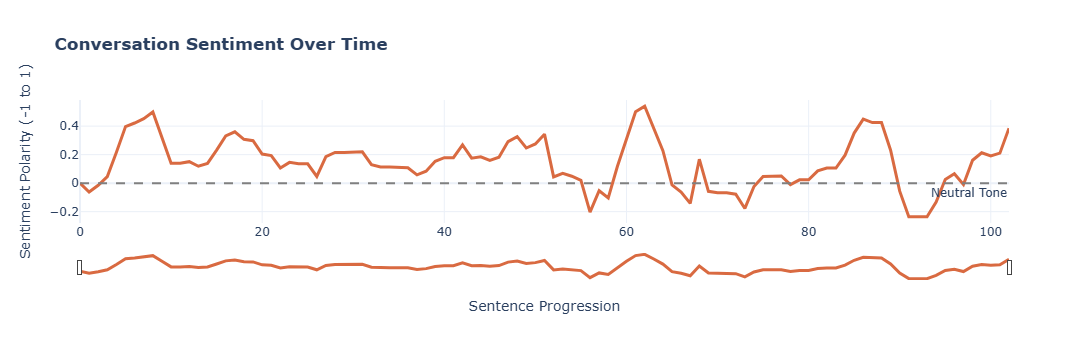

In [8]:
# Wrap the text using HTML tags
df_sentiment['Wrapped_Text'] = df_sentiment['Text'].apply(
    lambda x: '<br>'.join(textwrap.wrap(x, width=60))
)

# Initialize Plotly figure
fig1 = go.Figure()

# Add Rolling Average Line
fig1.add_trace(go.Scatter(
    x=df_sentiment['Sentence_Index'],
    y=df_sentiment['Rolling_Polarity'],
    mode='lines',
    name='5-Sentence Rolling Avg',
    line=dict(color='#D96A41', width=3),
    
    # Customize hover tool
    hovertemplate=
    '<b>Sentence %{x}</b><br>' +
    '<b>Rolling Polarity:</b> %{y:.2f}<br>' +
    '<br><b>Exact Quote:</b><br><i>%{customdata}</i><extra></extra>',
    customdata=df_sentiment['Wrapped_Text']
))

# Add Neutral Baseline
fig1.add_hline(
    y=0, 
    line_dash="dash", 
    line_color="gray", 
    annotation_text="Neutral Tone", 
    annotation_position="bottom right"
)

# Layout, Range Slider
fig1.update_layout(
    title='<b>Conversation Sentiment Over Time</b>',
    xaxis_title='Sentence Progression',
    yaxis_title='Sentiment Polarity (-1 to 1)',
    template='plotly_white',
    hovermode="x unified",
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="linear"
    )
)

fig1.show()

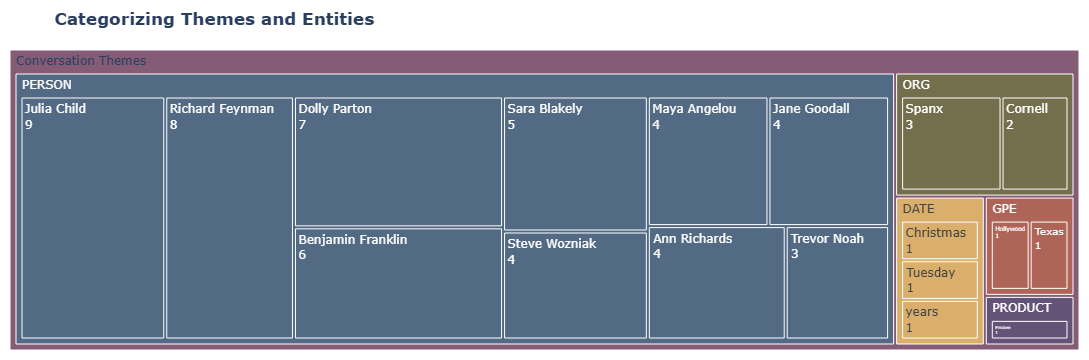

In [9]:
# Alias Map
alias_map = {
    "Benjamin Franklin": "Benjamin Franklin", "Ben Franklin": "Benjamin Franklin", "Ben": "Benjamin Franklin", "Franklin": "Benjamin Franklin",
    "Ann Richards": "Ann Richards", "Ann": "Ann Richards", "Richards": "Ann Richards",
    "Dolly Parton": "Dolly Parton", "Dolly": "Dolly Parton", "Parton": "Dolly Parton",
    "Trevor Noah": "Trevor Noah", "Trevor": "Trevor Noah", "Noah": "Trevor Noah",
    "Richard Feynman": "Richard Feynman", "Richard": "Richard Feynman", "Feynman": "Richard Feynman",
    "Jane Goodall": "Jane Goodall", "Jane": "Jane Goodall", "Goodall": "Jane Goodall",
    "Steve Wozniak": "Steve Wozniak", "The Woz": "Steve Wozniak", "Woz": "Steve Wozniak", "Wozniak": "Steve Wozniak",
    "Sara Blakely": "Sara Blakely", "Sara": "Sara Blakely", "Blakely": "Sara Blakely",
    "Maya Angelou": "Maya Angelou", "Maya": "Maya Angelou", "Angelou": "Maya Angelou",
    "Julia Child": "Julia Child", "Julia": "Julia Child", "Julia Childs": "Julia Child", "Child": "Julia Child",
}

if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    
    guest_patterns = [{"label": "PERSON", "pattern": name} for name in alias_map.keys()]
    ruler.add_patterns(guest_patterns)

doc = nlp(raw_text)

# Conversational filler words
junk_words = ["quantum", "the power dynamics", "the table", "dinner"]

# Build list of entities from doc
clean_entities = []

for ent in doc.ents:
    name = ent.text.strip()
    label = ent.label_
    
    # PASS 1: Is this a guest?
    if name in alias_map:
        clean_entities.append((alias_map[name], "PERSON"))
        continue # Skip the rest of the loop for this word
        
    # PASS 2: Is this our forced ORG list?
    if name in ["Spanx", "Cornell"]:
        clean_entities.append((name, "ORG"))
        continue
        
    # PASS 3: Clean up the remaining categories
    if label in ['ORG', 'GPE', 'DATE', 'EVENT', 'PRODUCT']:
        
        # RULE 1: Drop if it's too long
        if len(name.split()) > 3:
            continue
            
        # RULE 2: Drop if it's filler
        if name.lower() in junk_words:
            continue
            
        # RULE 3: Drop if contains guest name in phrase
        # (Catches "The entertainment & cultural icons Dolly Parton")
        is_corrupted_name = any(guest in name for guest in ["Dolly", "Franklin", "Feynman", "Julia", "Wozniak"])
        if is_corrupted_name:
            continue
            
        # Add to map
        clean_entities.append((name, label))

# Create DataFrame
df_ent = pd.DataFrame(clean_entities, columns=['Entity', 'Label'])
df_tree = df_ent.groupby(['Label', 'Entity']).size().reset_index(name='Count')

# Build the Treemap
fig2 = px.treemap(
    df_tree, 
    path=[px.Constant("Conversation Themes"), 'Label', 'Entity'], 
    values='Count',
    color='Label', 
    color_discrete_sequence=px.colors.qualitative.Antique,
    title='<b>Categorizing Themes and Entities</b>'
)

fig2.update_traces(
    textinfo="label+value",
    hovertemplate='<b>%{label}</b><br>Mentions: %{value}<extra></extra>'
)
fig2.update_layout(margin=dict(t=50, l=10, r=10, b=10))

fig2.show()

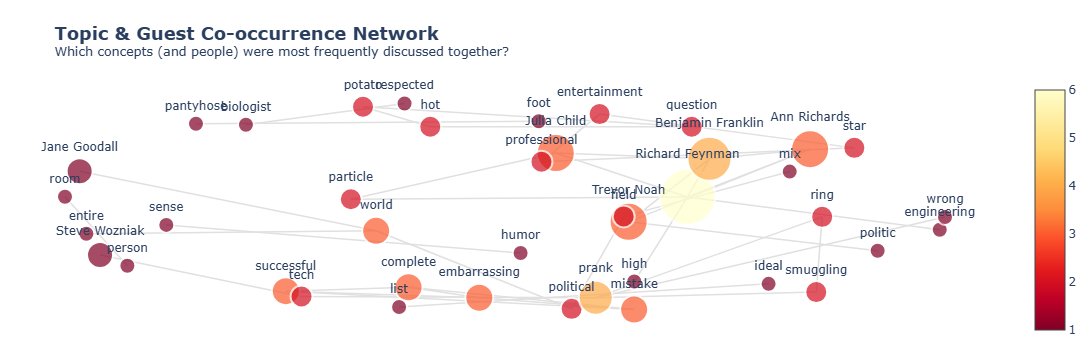

In [10]:
alias_map = {
    "Benjamin Franklin": "Benjamin Franklin", "Ben Franklin": "Benjamin Franklin", "Ben": "Benjamin Franklin", "Franklin": "Benjamin Franklin",
    "Ann Richards": "Ann Richards",
    "Dolly Parton": "Dolly Parton", "Dolly": "Dolly Parton",
    "Trevor Noah": "Trevor Noah",
    "Richard Feynman": "Richard Feynman", "Richard": "Richard Feynman", "Feynman": "Richard Feynman",
    "Jane Goodall": "Jane Goodall", "Jane": "Jane Goodall",
    "Steve Wozniak": "Steve Wozniak", "The Woz": "Steve Wozniak", "Woz": "Steve Wozniak", "Wozniak": "Steve Wozniak",
    "Sara Blakely": "Sara Blakely",
    "Maya Angelou": "Maya Angelou",
    "Julia Child": "Julia Child", "Julia": "Julia Child", "Julia Childs": "Julia Child",
}

valid_pos = ['NOUN', 'ADJ'] 
custom_stop_words = ["dinner", "table", "conversation", "guest", "time", "people", "way", "day", "thing"]
sentence_tokens = []

# Extract Guests and Topics
for sent in doc.sents:
    tokens_in_sent = set() 
    
    for ent in sent.ents:
        name = ent.text.strip()
        if name in alias_map:
            tokens_in_sent.add(alias_map[name])
            
    for token in sent:
        if token.pos_ in valid_pos and not token.is_stop and not token.is_punct:
            lemma = token.lemma_.lower().strip()
            if lemma not in custom_stop_words and len(lemma) > 2:
                if lemma not in [v.lower() for v in alias_map.values()]:
                    tokens_in_sent.add(lemma)
                    
    if len(tokens_in_sent) > 1:
        sentence_tokens.append(list(tokens_in_sent))

# Create connections
edges = []
for tokens in sentence_tokens:
    for pair in itertools.combinations(sorted(tokens), 2):
        edges.append(pair)

edge_counts = pd.Series(edges).value_counts().reset_index()
edge_counts.columns = ['Pair', 'Weight']

top_edges = edge_counts.head(40)

# Build Network
G = nx.Graph()
for index, row in top_edges.iterrows():
    G.add_edge(row['Pair'][0], row['Pair'][1], weight=row['Weight'])

pos = nx.spring_layout(G, k=1.2, iterations=50, seed=42)

# Extract Coordinates
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1.5, color='#E0E0E0'),
    hoverinfo='none', mode='lines'
)

# Extract Coordinates
node_x, node_y, node_text, node_size = [], [], [], []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x); node_y.append(y); node_text.append(node)
    
    base_size = G.degree(node) * 6 + 10
    node_size.append(base_size + 10 if node in alias_map.values() else base_size)

# Style Nodes
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=node_text,
    textposition="top center",
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlOrRd', reversescale=True,
        size=node_size,
        color=[G.degree(n) for n in G.nodes()],
        line_width=2, line_color='white'
    )
)

# Create Chart
fig3 = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(
                    text='<b>Topic & Guest Co-occurrence Network</b><br><sup>Which concepts (and people) were most frequently discussed together?</sup>',
                    font=dict(size=18)
                ),
                showlegend=False,
                hovermode='closest',
                height=800,
                margin=dict(b=20,l=5,r=5,t=80),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                plot_bgcolor='white', paper_bgcolor='white'
             ))

fig3.show()

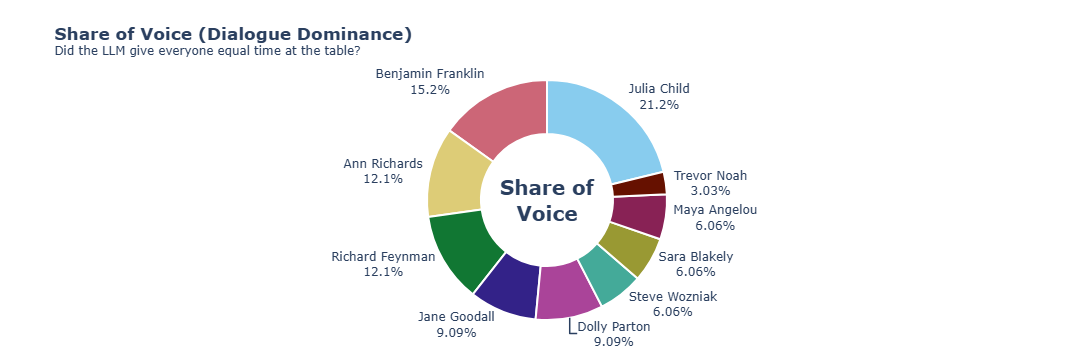

In [11]:
# Sort dataframe so the chart flows from largest to smallest
df_guests_sorted = df_guests.sort_values(by='Mentions', ascending=False)

# Build Donut Chart
fig4 = px.pie(
    df_guests_sorted, 
    names='Guest', 
    values='Mentions', 
    hole=0.55,
    color='Guest',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='<b>Share of Voice (Dialogue Dominance)</b><br><sup>Did the LLM give everyone equal time at the table?</sup>'
)

# Layout
fig4.update_traces(
    textposition='outside', 
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>Total Mentions/Dialogue: %{value} <br>Share of Conversation: %{percent}<extra></extra>',
    marker=dict(line=dict(color='#FFFFFF', width=2)) # Adds a clean white border between slices
)

fig4.update_layout(
    showlegend=False, # We don't need a legend since the labels are on the chart
    margin=dict(t=80, b=40, l=40, r=40),
    # Add a custom text annotation to the center of the donut
    annotations=[dict(text='<b>Share of<br>Voice</b>', x=0.5, y=0.5, font_size=20, showarrow=False)]
)

fig4.show()

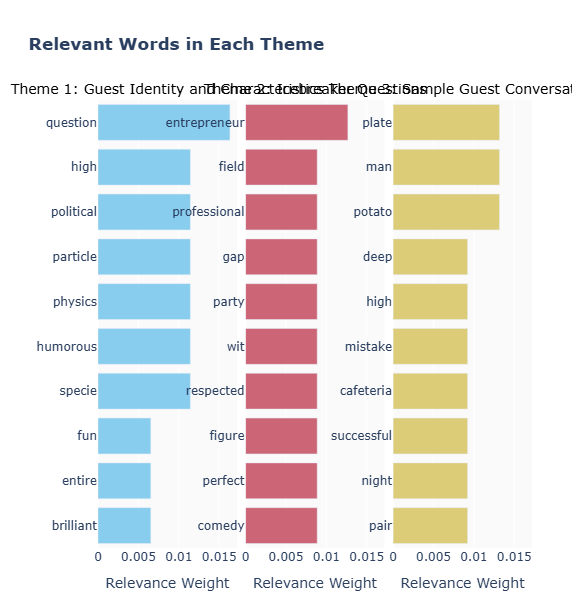

In [12]:
# Themes from LDA
topic_names = {
    0: "Theme 1: Guest Identity and Characteristics", 
    1: "Theme 2: Icebreaker Questions", 
    2: "Theme 3: Sample Guest Conversation"    
}

# Extract the Top 10 Words for each topic
topic_data = []

for topic_id in range(lda_model_bigram.num_topics):
    # show_topic returns a list of (word, probability) tuples
    top_terms = lda_model_bigram.show_topic(topic_id, topn=10)
    
    for word, weight in top_terms:
        topic_data.append({
            'Theme': topic_names[topic_id],
            'Word': word,
            'Importance': weight
        })

df_topics = pd.DataFrame(topic_data)

# Sort values
df_topics = df_topics.sort_values(by=['Theme', 'Importance'], ascending=[True, True])

# Build bar chart
fig5 = px.bar(
    df_topics,
    x='Importance',
    y='Word',
    color='Theme',
    facet_col='Theme',
    orientation='h',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='<b>Relevant Words in Each Theme</b>'
)

# Layout
fig5.update_yaxes(matches=None, showticklabels=True, title="")
fig5.update_xaxes(showgrid=True, title="Relevance Weight")

fig5.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1], font=dict(size=14, color="black")))

fig5.update_layout(
    height=600,
    showlegend=False,
    plot_bgcolor='#FAFAFA',
    margin=dict(t=100, b=40, l=40, r=40)
)

fig5.show()